<a href="https://colab.research.google.com/github/Gian-MR/LeetCode-Practice/blob/main/B03_Evaluar_TrustMark_Post_Deepfake.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# B03 — Evaluar TrustMark después del deepfake

Este notebook responde la pregunta central del Grupo B:

> **¿TrustMark sigue siendo detectable y recuperable después de que una imagen marcada pasa por SimSwap?**

Para cada par se evalúan dos condiciones:

```text
fake_control
    ↓
TrustMark.decode()
    ↓
debería ser negativo

fake_watermarked
    ↓
TrustMark.decode()
    ↓
¿sobrevivió la marca?
```

El `fake_control` nunca recibió TrustMark, por lo que sirve para medir falsos positivos.

El `fake_watermarked` proviene de:

```text
target original
      ↓
TrustMark
      ↓
target marcado
      ↓
SimSwap
      ↓
fake_watermarked
```

Las métricas principales serán:

- detection rate;
- bit accuracy entre marcas detectadas;
- BER;
- exact recovery rate;
- false positive rate sobre los controles.


In [ ]:
# ============================================================
# CELDA 1 — Instalación de dependencias
# Instala TrustMark y sus dependencias auxiliares utilizando la
# misma estrategia empleada en los notebooks anteriores para
# evitar conflictos con NumPy y PyTorch del runtime de Colab.
# ============================================================

import sys
import subprocess
import importlib.util

subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q",
    "omegaconf>=2.1",
    "lightning>=2.0",
    "six>=1.9",
    "einops>=0.4.0",
])

if importlib.util.find_spec("trustmark") is None:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install",
        "--no-deps",
        "trustmark==0.9.1",
    ])

print("✓ Dependencias listas.")


✓ Dependencias listas.


In [ ]:
# ============================================================
# CELDA 2 — Importaciones
# Importa las librerías necesarias para leer manifests, manejar
# imágenes, decodificar TrustMark, calcular métricas y generar
# las tablas y figuras del análisis posterior al deepfake.
# ============================================================

from pathlib import Path
import json
import hashlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from IPython.display import display

from trustmark import TrustMark

print("✓ Importaciones listas.")


✓ Importaciones listas.


In [ ]:
# ============================================================
# CELDA 3 — Google Drive y estructura del proyecto
# Monta Google Drive y define las rutas de entrada provenientes
# de B01 y B02, además de las carpetas persistentes donde se
# guardarán resultados, configuración y figuras de B03.
# ============================================================

try:
    from google.colab import drive

    drive.mount("/content/drive")

    ROOT = Path(
        "/content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026"
    )

except Exception:
    ROOT = Path.cwd() / "Investigacion_Deepfake_Watermarking_2026"


B01_ROOT = (
    ROOT
    / "results"
    / "grupo_B"
    / "trustmark_targets"
    / "smoke_10"
)

B01_CONFIG = B01_ROOT / "config.json"
B01_METRICS = B01_ROOT / "metrics.csv"


B02_ROOT = (
    ROOT
    / "results"
    / "grupo_B"
    / "simswap"
    / "smoke_10"
)

B02_MANIFEST = B02_ROOT / "manifest.csv"


OUT_ROOT = (
    ROOT
    / "results"
    / "grupo_B"
    / "trustmark_post_deepfake"
    / "smoke_10"
)

OUT_RESULTS = OUT_ROOT / "results.csv"
OUT_SUMMARY = OUT_ROOT / "summary.csv"
OUT_CONFIG = OUT_ROOT / "config.json"


FIG_ROOT = (
    ROOT
    / "figures"
    / "grupo_B"
    / "trustmark_post_deepfake"
)

FIG_DETECTION = (
    FIG_ROOT
    / "detection_control_vs_watermarked.png"
)

FIG_RECOVERY = (
    FIG_ROOT
    / "watermark_recovery_post_deepfake.png"
)


OUT_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

FIG_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)


print("Manifest B02:")
print(B02_MANIFEST)
print()
print("Resultados B03:")
print(OUT_ROOT)


Mounted at /content/drive
Manifest B02:
/content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026/results/grupo_B/simswap/smoke_10/manifest.csv

Resultados B03:
/content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026/results/grupo_B/trustmark_post_deepfake/smoke_10


In [ ]:
# ============================================================
# CELDA 4 — Validación de las entradas
# Comprueba que existen los archivos producidos por B01 y B02
# y que cada par contiene tanto un fake_control como un
# fake_watermarked antes de comenzar la decodificación.
# ============================================================

assert B01_CONFIG.exists(), (
    f"No se encontró la configuración de B01:\n{B01_CONFIG}"
)

assert B01_METRICS.exists(), (
    f"No se encontraron las métricas de B01:\n{B01_METRICS}"
)

assert B02_MANIFEST.exists(), (
    f"No se encontró el manifest de B02:\n{B02_MANIFEST}"
)


manifest_b02 = pd.read_csv(
    B02_MANIFEST
)

metrics_b01 = pd.read_csv(
    B01_METRICS
)


required_columns = {
    "pair_id",
    "fake_control",
    "fake_watermarked",
    "target_original",
    "target_watermarked",
    "source_frame",
}

missing_columns = (
    required_columns
    - set(manifest_b02.columns)
)

assert not missing_columns, (
    f"Faltan columnas en B02: {sorted(missing_columns)}"
)


for column in [
    "fake_control",
    "fake_watermarked",
]:

    missing_files = [
        p
        for p in manifest_b02[
            column
        ].astype(str)
        if not Path(p).exists()
    ]

    assert not missing_files, (
        f"Hay archivos faltantes en {column}: "
        f"{missing_files[:3]}"
    )


print("✓ Entradas validadas.")
print("Número de pares:", len(manifest_b02))


✓ Entradas validadas.
Número de pares: 5


In [ ]:
# ============================================================
# CELDA 5 — Recuperar la configuración de TrustMark
# Lee exactamente el modelo, codificación, fuerza y payload
# utilizados en B01. Esto garantiza que B03 intenta recuperar
# la misma marca que estaba presente antes del face swap.
# ============================================================

with open(
    B01_CONFIG,
    "r",
    encoding="utf-8",
) as f:

    trustmark_config = json.load(
        f
    )


MODEL_TYPE = trustmark_config[
    "model_type"
]

ENCODING_NAME = trustmark_config[
    "encoding"
]

WM_STRENGTH = float(
    trustmark_config[
        "wm_strength"
    ]
)

PAYLOAD = str(
    trustmark_config[
        "payload"
    ]
)

PAYLOAD_BITS = int(
    trustmark_config[
        "payload_bits"
    ]
)

PAYLOAD_SHA256 = trustmark_config[
    "payload_sha256"
]


assert hashlib.sha256(
    PAYLOAD.encode("utf-8")
).hexdigest() == PAYLOAD_SHA256, (
    "El payload no coincide con el hash registrado en B01."
)


print("Modelo:", MODEL_TYPE)
print("Encoding:", ENCODING_NAME)
print("Strength:", WM_STRENGTH)
print("Payload bits:", PAYLOAD_BITS)
print("Payload SHA-256:", PAYLOAD_SHA256)


Modelo: Q
Encoding: BCH_5
Strength: 1.0
Payload bits: 61
Payload SHA-256: 32cc4a9fb90d3362df03b81fc615a8ab229ea8cb012e1db52efd58d1291874fe


In [ ]:
# ============================================================
# CELDA 6 — Inicialización de TrustMark
# Inicializa el decoder con la misma arquitectura y esquema BCH
# usados al insertar la marca. La decodificación se realiza en
# modo binario, igual que en los experimentos anteriores.
# ============================================================

ENCODING_TYPE = getattr(
    TrustMark.Encoding,
    ENCODING_NAME,
)

tm = TrustMark(
    verbose=True,
    model_type=MODEL_TYPE,
    encoding_type=ENCODING_TYPE,
    loadRemover=False,
    loadBBoxDetector=False,
)


assert tm.schemaCapacity() == PAYLOAD_BITS, (
    "La capacidad del decoder no coincide con la registrada en B01."
)


print("✓ TrustMark inicializado.")


Initializing TrustMark watermarking with ECC using [cuda]
Fetching model file (once only): /usr/local/lib/python3.13/dist-packages/trustmark/models/trustmark_Q.yaml
Fetching model file (once only): /usr/local/lib/python3.13/dist-packages/trustmark/models/decoder_Q.ckpt
Fetching model file (once only): /usr/local/lib/python3.13/dist-packages/trustmark/models/encoder_Q.ckpt
✓ TrustMark inicializado.


In [ ]:
# ============================================================
# CELDA 7 — Funciones auxiliares de recuperación
# Define la exactitud de bits y una función común para ejecutar
# TrustMark.decode() sobre cada imagen y devolver detección,
# BER, bit accuracy y recuperación exacta del payload.
# ============================================================

def bit_accuracy(
    expected,
    recovered,
):

    if recovered is None:
        return np.nan

    recovered = str(
        recovered
    )

    if len(recovered) == 0:
        return np.nan

    correct = sum(
        a == b
        for a, b in zip(
            expected,
            recovered,
        )
    )

    return (
        correct
        / len(expected)
    )


def decode_image(
    image_path,
):

    with Image.open(
        image_path
    ) as img:

        image = (
            img
            .convert("RGB")
            .copy()
        )


    recovered, present, schema = tm.decode(
        image,
        MODE="binary",
        DETECTFIRST=False,
        ROTATION=False,
    )


    if present:

        accuracy = bit_accuracy(
            PAYLOAD,
            recovered,
        )

        ber = (
            1.0 - accuracy
            if not np.isnan(
                accuracy
            )
            else np.nan
        )

        exact = bool(
            str(recovered)
            == PAYLOAD
        )

    else:

        accuracy = np.nan
        ber = np.nan
        exact = False


    return {
        "watermark_present": bool(
            present
        ),
        "recovered_payload": (
            str(recovered)
            if recovered is not None
            else None
        ),
        "schema": (
            str(schema)
            if schema is not None
            else None
        ),
        "bit_accuracy_detected": accuracy,
        "ber_detected": ber,
        "exact_recovery": exact,
    }


In [ ]:
# ============================================================
# CELDA 8 — Decodificación de ambas condiciones
# Evalúa cada fake_control y fake_watermarked. El control nunca
# recibió TrustMark y permite medir falsos positivos; la condición
# watermarked permite medir la supervivencia real de la marca.
# ============================================================

rows = []


for row in manifest_b02.itertuples(
    index=False
):

    pair_id = str(
        row.pair_id
    )


    conditions = [
        (
            "fake_control",
            Path(
                row.fake_control
            ),
            False,
        ),
        (
            "fake_watermarked",
            Path(
                row.fake_watermarked
            ),
            True,
        ),
    ]


    for (
        condition,
        image_path,
        expected_watermark,
    ) in conditions:

        decoded = decode_image(
            image_path
        )


        rows.append({
            "pair_id": pair_id,
            "condition": condition,
            "image_path": str(
                image_path
            ),
            "expected_watermark": bool(
                expected_watermark
            ),
            "watermark_present": decoded[
                "watermark_present"
            ],
            "recovered_payload": decoded[
                "recovered_payload"
            ],
            "schema": decoded[
                "schema"
            ],
            "bit_accuracy_detected": decoded[
                "bit_accuracy_detected"
            ],
            "ber_detected": decoded[
                "ber_detected"
            ],
            "exact_recovery": decoded[
                "exact_recovery"
            ],
        })


results = pd.DataFrame(
    rows
)


display(
    results
)


,pair_id,condition,image_path,expected_watermark,watermark_present,recovered_payload,schema,bit_accuracy_detected,ber_detected,exact_recovery
0,pair_001,fake_control,/content/drive/MyDrive/Investigacion_Deepfake_...,False,False,,-1,NaN,NaN,False
1,pair_001,fake_watermarked,/content/drive/MyDrive/Investigacion_Deepfake_...,True,True,0100111000010101101111101011101011110110111111...,1,1.0,0.0,True
2,pair_002,fake_control,/content/drive/MyDrive/Investigacion_Deepfake_...,False,False,,-1,NaN,NaN,False
3,pair_002,fake_watermarked,/content/drive/MyDrive/Investigacion_Deepfake_...,True,True,0100111000010101101111101011101011110110111111...,1,1.0,0.0,True
4,pair_003,fake_control,/content/drive/MyDrive/Investigacion_Deepfake_...,False,False,,-1,NaN,NaN,False
5,pair_003,fake_watermarked,/content/drive/MyDrive/Investigacion_Deepfake_...,True,True,0100111000010101101111101011101011110110111111...,1,1.0,0.0,True
6,pair_004,fake_control,/content/drive/MyDrive/Investigacion_Deepfake_...,False,False,,-1,NaN,NaN,False
7,pair_004,fake_watermarked,/content/drive/MyDrive/Investigacion_Deepfake_...,True,True,0100111000010101101111101011101011110110111111...,1,1.0,0.0,True
8,pair_005,fake_control,/content/drive/MyDrive/Investigacion_Deepfake_...,False,False,,-1,NaN,NaN,False
9,pair_005,fake_watermarked,/content/drive/MyDrive/Investigacion_Deepfake_...,True,True,0100111000010101101111101011101011110110111111...,1,1.0,0.0,True


In [ ]:
# ============================================================
# CELDA 9 — Resumen por condición
# Resume detection rate, bit accuracy, BER y recuperación exacta
# por separado para controles y deepfakes provenientes de targets
# marcados. En los controles, detection rate equivale a FPR.
# ============================================================

summary_rows = []


for condition, group in results.groupby(
    "condition"
):

    detected = group[
        "watermark_present"
    ].astype(bool)

    expected_mark = bool(
        group[
            "expected_watermark"
        ].iloc[0]
    )


    summary_rows.append({
        "condition": condition,
        "n": len(
            group
        ),
        "expected_watermark": expected_mark,
        "detected_count": int(
            detected.sum()
        ),
        "detection_rate": float(
            detected.mean()
        ),
        "false_positive_rate": (
            float(
                detected.mean()
            )
            if not expected_mark
            else np.nan
        ),
        "mean_bit_accuracy_detected": float(
            group[
                "bit_accuracy_detected"
            ].mean()
        )
        if detected.any()
        else np.nan,
        "mean_ber_detected": float(
            group[
                "ber_detected"
            ].mean()
        )
        if detected.any()
        else np.nan,
        "exact_recovery_count": int(
            group[
                "exact_recovery"
            ].sum()
        ),
        "exact_recovery_rate": float(
            group[
                "exact_recovery"
            ].mean()
        ),
    })


summary = pd.DataFrame(
    summary_rows
)


display(
    summary
)


,condition,n,expected_watermark,detected_count,detection_rate,false_positive_rate,mean_bit_accuracy_detected,mean_ber_detected,exact_recovery_count,exact_recovery_rate
0,fake_control,5,False,0,0.0,0.0,NaN,NaN,0,0.0
1,fake_watermarked,5,True,5,1.0,NaN,1.0,0.0,5,1.0


In [ ]:
# ============================================================
# CELDA 10 — Comparación con la línea base de B01
# Compara el estado de TrustMark inmediatamente antes del face
# swap con el estado posterior en fake_watermarked. Esta tabla
# permite observar directamente qué cambió después de SimSwap.
# ============================================================

pre = metrics_b01[
    [
        "pair_id",
        "watermark_present",
        "bit_accuracy_detected",
        "ber_detected",
        "exact_recovery",
    ]
].copy()

pre = pre.rename(
    columns={
        "watermark_present": "pre_watermark_present",
        "bit_accuracy_detected": "pre_bit_accuracy",
        "ber_detected": "pre_ber",
        "exact_recovery": "pre_exact_recovery",
    }
)


post = results[
    results[
        "condition"
    ] == "fake_watermarked"
][
    [
        "pair_id",
        "watermark_present",
        "bit_accuracy_detected",
        "ber_detected",
        "exact_recovery",
    ]
].copy()

post = post.rename(
    columns={
        "watermark_present": "post_watermark_present",
        "bit_accuracy_detected": "post_bit_accuracy",
        "ber_detected": "post_ber",
        "exact_recovery": "post_exact_recovery",
    }
)


pre_post = pre.merge(
    post,
    on="pair_id",
    how="inner",
)


display(
    pre_post
)


,pair_id,pre_watermark_present,pre_bit_accuracy,pre_ber,pre_exact_recovery,post_watermark_present,post_bit_accuracy,post_ber,post_exact_recovery
0,pair_001,True,1.0,0.0,True,True,1.0,0.0,True
1,pair_002,True,1.0,0.0,True,True,1.0,0.0,True
2,pair_003,True,1.0,0.0,True,True,1.0,0.0,True
3,pair_004,True,1.0,0.0,True,True,1.0,0.0,True
4,pair_005,True,1.0,0.0,True,True,1.0,0.0,True


In [ ]:
# ============================================================
# CELDA 11 — Guardado de resultados y configuración
# Guarda los resultados individuales, el resumen por condición
# y la configuración utilizada para que el análisis del Grupo B
# pueda reproducirse posteriormente con más imágenes.
# ============================================================

results.to_csv(
    OUT_RESULTS,
    index=False,
)

summary.to_csv(
    OUT_SUMMARY,
    index=False,
)


config = {
    "group": "B",
    "stage": "B03",
    "generator": "SimSwap",
    "model_type": MODEL_TYPE,
    "encoding": ENCODING_NAME,
    "wm_strength": WM_STRENGTH,
    "payload_bits": PAYLOAD_BITS,
    "payload_sha256": PAYLOAD_SHA256,
    "mode": "binary",
    "detectfirst": False,
    "rotation": False,
    "input_manifest": str(
        B02_MANIFEST
    ),
    "baseline_metrics": str(
        B01_METRICS
    ),
    "n_pairs": int(
        manifest_b02[
            "pair_id"
        ].nunique()
    ),
    "conditions": [
        "fake_control",
        "fake_watermarked",
    ],
    "results": str(
        OUT_RESULTS
    ),
    "summary": str(
        OUT_SUMMARY
    ),
}


with open(
    OUT_CONFIG,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        config,
        f,
        indent=2,
        ensure_ascii=False,
    )


print("Resultados:")
print(OUT_RESULTS)
print()
print("Resumen:")
print(OUT_SUMMARY)
print()
print("Configuración:")
print(OUT_CONFIG)


Resultados:
/content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026/results/grupo_B/trustmark_post_deepfake/smoke_10/results.csv

Resumen:
/content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026/results/grupo_B/trustmark_post_deepfake/smoke_10/summary.csv

Configuración:
/content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026/results/grupo_B/trustmark_post_deepfake/smoke_10/config.json


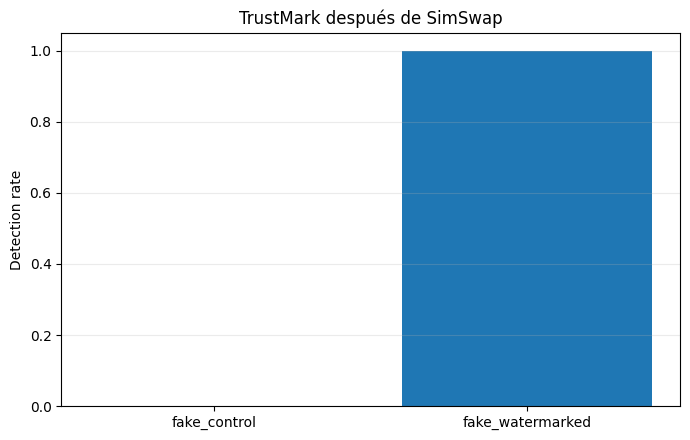

Figura:
/content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026/figures/grupo_B/trustmark_post_deepfake/detection_control_vs_watermarked.png


In [ ]:
# ============================================================
# CELDA 12 — Figura de detección
# Compara la tasa de detección entre los fake_control y los
# fake_watermarked. En los controles, cualquier detección se
# interpreta como un falso positivo.
# ============================================================

plot_data = (
    summary
    .set_index(
        "condition"
    )
)


conditions = [
    "fake_control",
    "fake_watermarked",
]

values = [
    plot_data.loc[
        condition,
        "detection_rate",
    ]
    for condition in conditions
]


fig, ax = plt.subplots(
    figsize=(
        7,
        4.5,
    )
)

ax.bar(
    conditions,
    values,
)

ax.set_ylim(
    0,
    1.05,
)

ax.set_ylabel(
    "Detection rate"
)

ax.set_title(
    "TrustMark después de SimSwap"
)

ax.grid(
    axis="y",
    alpha=0.25,
)

plt.tight_layout()

plt.savefig(
    FIG_DETECTION,
    dpi=180,
    bbox_inches="tight",
)

plt.show()


print("Figura:")
print(FIG_DETECTION)


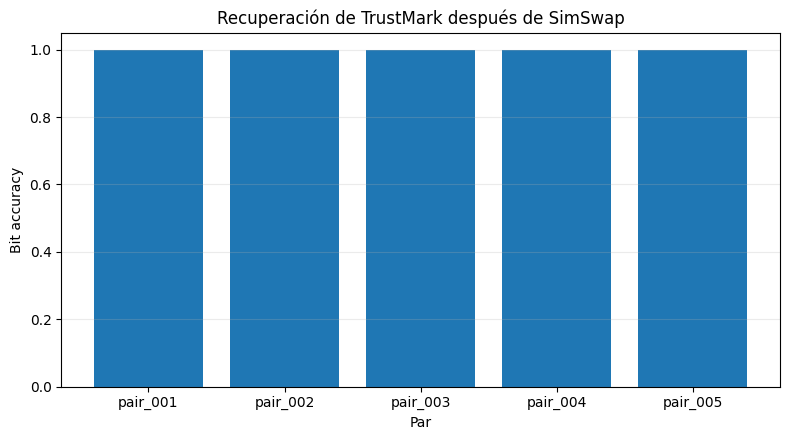

Figura:
/content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026/figures/grupo_B/trustmark_post_deepfake/watermark_recovery_post_deepfake.png


In [ ]:
# ============================================================
# CELDA 13 — Recuperación del payload después del deepfake
# Visualiza por par si TrustMark fue detectado, la exactitud de
# bits recuperados y si la recuperación fue exacta después de
# pasar por SimSwap.
# ============================================================

wm = (
    results[
        results[
            "condition"
        ] == "fake_watermarked"
    ]
    .copy()
    .sort_values(
        "pair_id"
    )
)


fig, ax = plt.subplots(
    figsize=(
        8,
        4.5,
    )
)


values = (
    wm[
        "bit_accuracy_detected"
    ]
    .fillna(
        0.0
    )
    .values
)


ax.bar(
    wm[
        "pair_id"
    ],
    values,
)


ax.set_ylim(
    0,
    1.05,
)

ax.set_ylabel(
    "Bit accuracy"
)

ax.set_xlabel(
    "Par"
)

ax.set_title(
    "Recuperación de TrustMark "
    "después de SimSwap"
)

ax.grid(
    axis="y",
    alpha=0.25,
)


plt.tight_layout()

plt.savefig(
    FIG_RECOVERY,
    dpi=180,
    bbox_inches="tight",
)

plt.show()


print("Figura:")
print(FIG_RECOVERY)


In [ ]:
# ============================================================
# CELDA 14 — Resumen final de B03
# Presenta los indicadores principales del experimento:
# supervivencia de TrustMark en fake_watermarked y tasa de
# falsos positivos observada en fake_control.
# ============================================================

control = summary[
    summary[
        "condition"
    ] == "fake_control"
].iloc[0]

watermarked = summary[
    summary[
        "condition"
    ] == "fake_watermarked"
].iloc[0]


print(
    "============================================================"
)

print(
    " B03 COMPLETADO"
)

print(
    "============================================================"
)

print()

print(
    "FAKE WATERMARKED"
)

print(
    f"Detection rate:      "
    f"{watermarked['detection_rate']:.3f}"
)

print(
    f"Bit accuracy:        "
    f"{watermarked['mean_bit_accuracy_detected']:.3f}"
)

print(
    f"BER:                 "
    f"{watermarked['mean_ber_detected']:.3f}"
)

print(
    f"Exact recovery rate: "
    f"{watermarked['exact_recovery_rate']:.3f}"
)

print()

print(
    "FAKE CONTROL"
)

print(
    f"False positive rate: "
    f"{control['false_positive_rate']:.3f}"
)

print()

print(
    "Interpretación:"
)

print(
    "B03 mide si una marca válida antes del "
    "face swap continúa siendo recuperable después "
    "de la manipulación."
)


 B03 COMPLETADO

FAKE WATERMARKED
Detection rate:      1.000
Bit accuracy:        1.000
BER:                 0.000
Exact recovery rate: 1.000

FAKE CONTROL
False positive rate: 0.000

Interpretación:
B03 mide si una marca válida antes del face swap continúa siendo recuperable después de la manipulación.
